# Scenario: Classic RCT

We call 'Classic Randomized Controlled Trial' (RCT) a scenario where a treatment is randomly assigned to participants, and we do not have pre-experiment data of participants like pre-treatment outcome.

Treatment - new onboarding for new users.

We will test hypothesis:

$H_o$ - There is no difference in conversion rate between treatment and control groups.

$H_a$ - There is a difference in conversion rate between treatment and control groups.

# Causal Assumptions

**Unconfoundedness**: random assignment of treatment. Will be tested with SRM and Balance Check

**Overlap**: each unit has a non-zero probability of assignment to every arm. By design

**SUTVA**: no interference and consistent treatment definitions. By design

# Data

For the analysis you need data in pandas dataframe:
- treatment column in binary format (1/0)
- outcome column numeric format, measured after treatment time
- user_id column (Optional, but useful)
- confounders columns (Optional, measured before treatment time, numeric format, used for causal assumption check)

We will take data from Causalis DGP. More you can read at https://causalis.causalcraft.com/articles/generate_classic_rct_26

In [1]:
from causalis.scenarios.classic_rct.dgp import generate_classic_rct_26
from causalis.data_contracts import CausalData

data = generate_classic_rct_26(return_causal_data=False, include_oracle=True)
data.head()

,user_id,conversion,d,platform_ios,country_usa,source_paid,m,m_obs,tau_link,g0,g1,cate
0,01fc4,0.0,0.0,1.0,0.0,1.0,0.5,0.5,0.106483,0.310620,0.333868,0.023249
1,0204c,0.0,1.0,0.0,0.0,1.0,0.5,0.5,0.106483,0.198257,0.215727,0.017471
2,002cf,0.0,0.0,1.0,1.0,0.0,0.5,0.5,0.106483,0.231969,0.251479,0.019509
3,0202d,0.0,1.0,1.0,1.0,0.0,0.5,0.5,0.106483,0.231969,0.251479,0.019509
4,011cb,0.0,1.0,0.0,1.0,0.0,0.5,0.5,0.106483,0.142189,0.155678,0.013489


In [2]:
causaldata = CausalData(df = data,
                        treatment='d',
                        outcome='conversion',
                        confounders=['platform_ios', 'country_usa', 'source_paid'])
causaldata

CausalData(df=(10000, 5), treatment='d', outcome='conversion', confounders=['platform_ios', 'country_usa', 'source_paid'])

# EDA

In [3]:
from causalis.shared import outcome_stats
outcome_stats(causaldata)

,treatment,count,mean,std,min,p10,p25,median,p75,p90,max
0,0,4955,0.198991,0.399281,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,1,5045,0.232904,0.422723,0.0,0.0,0.0,0.0,0.0,1.0,1.0


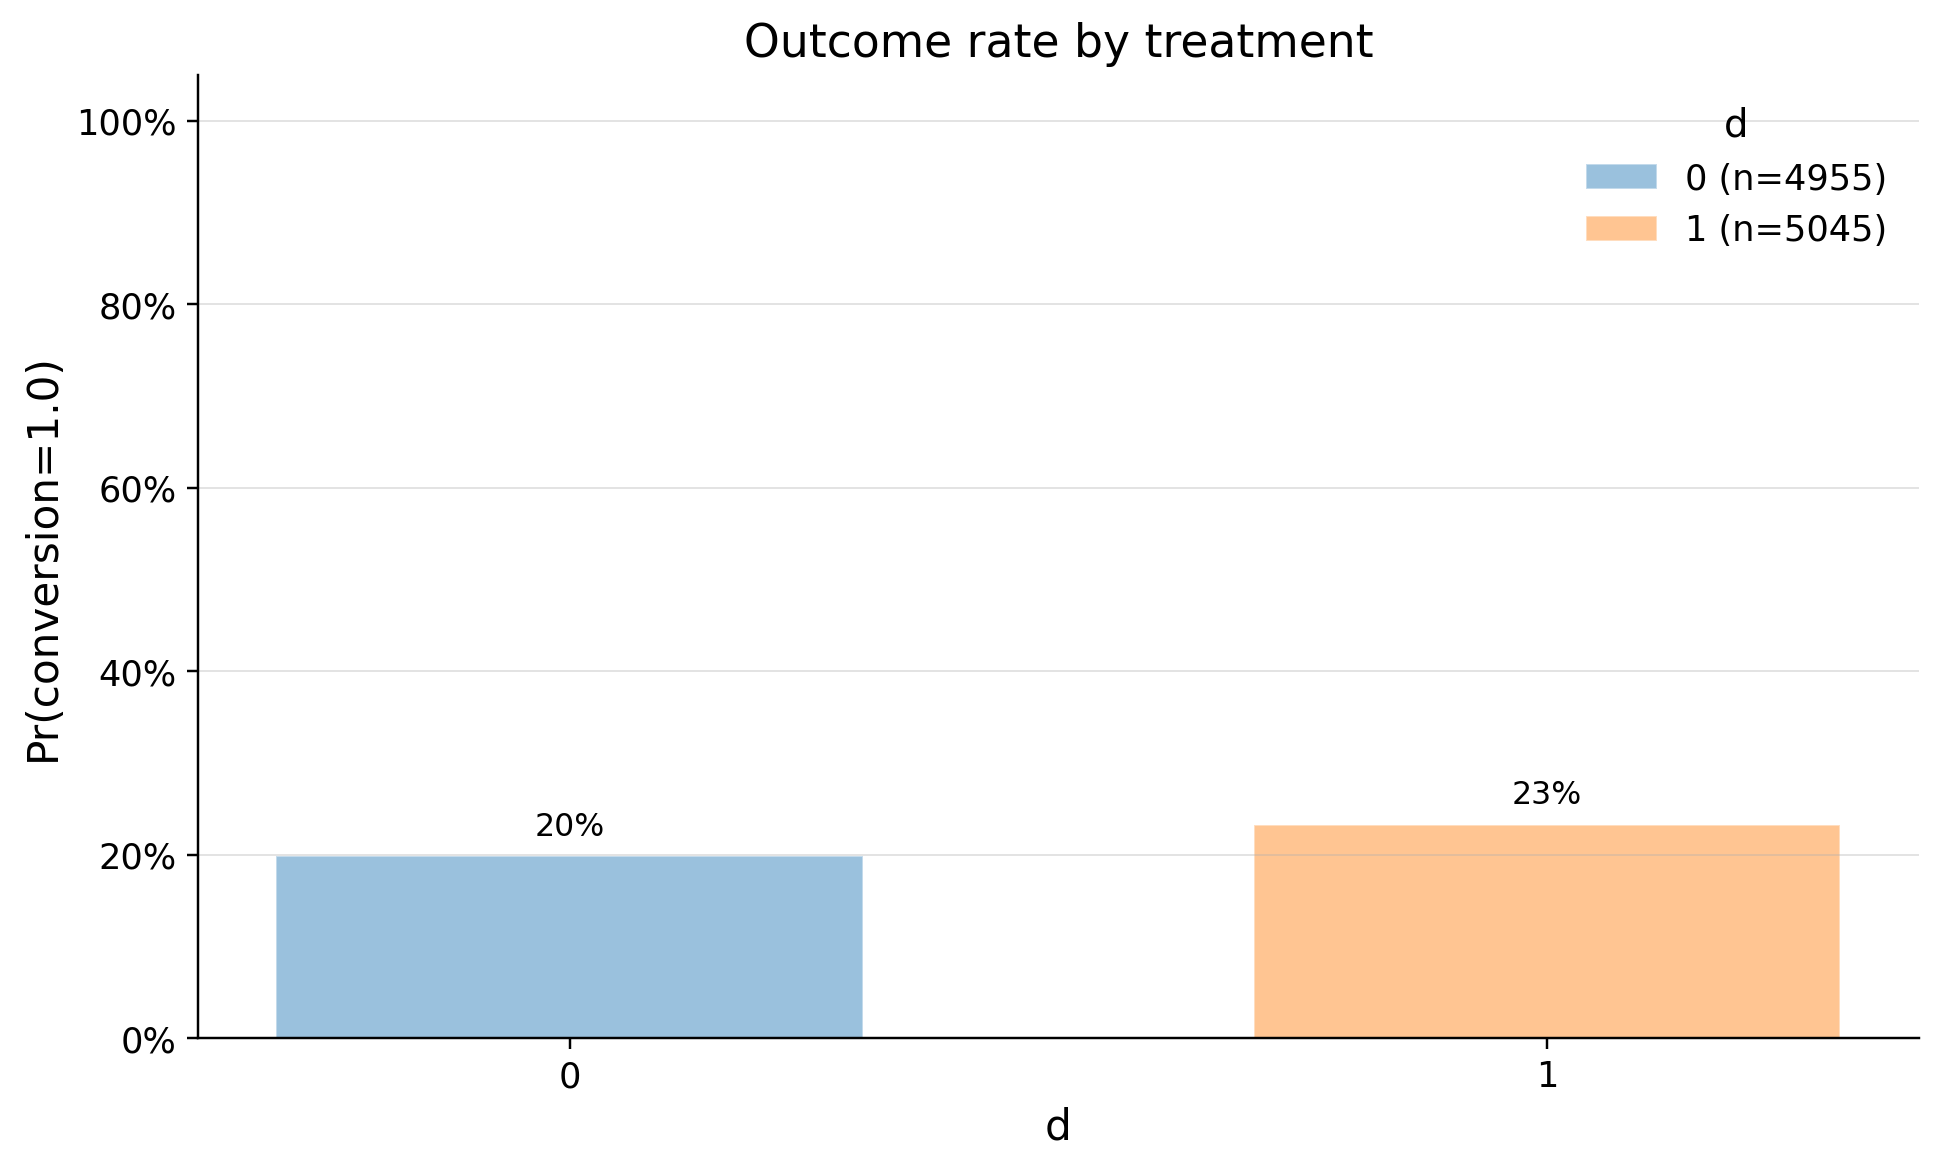

In [4]:
from causalis.shared import outcome_plot_dist
outcome_plot_dist(causaldata)

# SRM

Our system is randomly splitting users. Half of them must have new onboarding, other half has not. We should monitor the split with SRM test. Read more at https://causalis.causalcraft.com/articles/srm

In [5]:
from causalis.shared import check_srm

check_srm(assignments=causaldata, target_allocation={0: 0.5, 1: 0.5}, alpha=0.001)

SRMResult(status=no SRM, p_value=0.36812, chi2=0.8100)

# Confounders balance

Are groups equal in terms of confounders? We need to choose with domain and business sense confounders and check balance of them.
The standard benchmark:

- $SMD > 0.1$
- `ks_pvalue` < 0.05

In [6]:
from causalis.shared import confounders_balance

confounders_balance(causaldata)

,confounders,mean_d_0,mean_d_1,abs_diff,smd,ks_pvalue
0,source_paid,0.299092,0.313776,0.014684,0.031853,0.64592
1,platform_ios,0.494046,0.502874,0.008828,0.017654,0.98861
2,country_usa,0.586276,0.591873,0.005597,0.011374,1.00000


As we see system splitted users randomly

# SUTVA

In [7]:
from causalis.shared import print_sutva_questions
print_sutva_questions()

1.) Are your clients independent (i). Outcome of ones do not depend on others?
2.) Are all clients have full window to measure metrics?
3.) Do you measure confounders before treatment and outcome after?
4.) Do you have a consistent label of treatment, such as if a person does not receive a treatment, he has a label 0?


# Estimation with Diff-in-Means

In [8]:
from causalis.scenarios.classic_rct.model import DiffInMeans

model = DiffInMeans().fit(causaldata)

In `Causalis.DiffInMeans` model implemented `ttest`, `conversion_ztest` and `welch_permutation_t_test`:
- use `conversion_ztest` when users < 100k and outcome is binary
- use `welch_permutation_t_test` when users < 10k or outcome is ratio metric or your metric is highly skewed
- in other cases use `ttest`

Read more in https://causalis.causalcraft.com/articles/rct-classic-model

We will use `conversion_ztest` for our scenario

In [9]:
result_conversion = model.estimate('conversion_ztest')
result_conversion.summary()

,value
field,
estimand,ATE
model,DiffInMeans
value,"0.0339 (ci_abs: 0.0111, 0.0567)"
value_relative,"17.0425 (ci_rel: 8.2614, 25.8235)"
alpha,0.0500
p_value,0.0000
is_significant,True
n_treated,5045
n_control,4955


Let's compare ATE with oracle effect

In [10]:
print(f"Ground truth ATE is {data['cate'].mean()}")

Ground truth ATE is 0.01719144406311028
